# Hybrid ECG Classifier — PyTorch (Enhanced)

RTX 4050 6GB build with:
- Mixed precision (AMP) + TF32 + cuDNN benchmark
- Gradient clipping, deterministic seeds, OOM-safe data loading
- Pre-flight sanity check (catches broken files / shape mismatches before training)
- Live progress with GPU memory readout
- **3D visualizations**: loss landscape, embedding space (PCA-3D), AUC vs LR surface
- Confusion matrix + ROC curve + per-threshold metric sweep

In [1]:
# ==========================================
# 1. IMPORTS
# ==========================================
import os, ast, math, time, json, random, gc, warnings
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa — registers 3D projection
from matplotlib import cm
from tqdm.auto import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, precision_score, recall_score,
                             accuracy_score, confusion_matrix, roc_curve)
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

warnings.filterwarnings("ignore", category=UserWarning)

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device  :", torch.cuda.get_device_name(0))
    print("VRAM    :", f"{torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")

PyTorch : 2.6.0+cu124
CUDA    : True
Device  : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM    : 6.44 GB


In [2]:
# ==========================================
# 2. CONFIG + REPRODUCIBILITY
# ==========================================
BASE_PATH   = "data/ptb-xl"
CSV_PATH    = os.path.join(BASE_PATH, "ptbxl_database.csv")
IMAGE_PATH  = os.path.join(BASE_PATH, "images")

USE_HIGH_RES          = False
EXPECTED_SIGNAL_SHAPE = (5000, 12) if USE_HIGH_RES else (1000, 12)

# Tuned for RTX 4050 6GB with AMP
BATCH_SIZE    = 16
EPOCHS        = 15
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
GRAD_CLIP     = 1.0
NUM_WORKERS   = 0
PIN_MEMORY    = True
USE_AMP       = True
SEED          = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Deterministic-ish seeds (keep cudnn.benchmark=True for speed; turn off for full determinism)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Speed knobs
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")   # TF32 on Ampere/Ada — free speed
if hasattr(torch.backends.cuda, "matmul"):
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

os.makedirs("models", exist_ok=True)
os.makedirs("logs",   exist_ok=True)

print(f"Device: {DEVICE} | AMP: {USE_AMP} | batch: {BATCH_SIZE} | workers: {NUM_WORKERS}")

Device: cuda | AMP: True | batch: 16 | workers: 0


In [3]:
# ==========================================
# 3. LOAD METADATA & BUILD LABELS
# ==========================================
df = pd.read_csv(CSV_PATH)

def get_label(scp_str):
    try:
        scp_dict  = ast.literal_eval(scp_str)
        confirmed = {k: v for k, v in scp_dict.items() if v >= 50}
        if len(confirmed) == 0:
            return -1
        return 0 if "NORM" in confirmed else 1
    except Exception:
        return -1

df["label"] = df["scp_codes"].apply(get_label)
df = df[df["label"] != -1].reset_index(drop=True)

# Quick image-existence filter — avoids per-batch surprise IO errors during training
print("Checking image files exist (one-time pass)...")
exists_mask = df["ecg_id"].apply(lambda eid: os.path.exists(os.path.join(IMAGE_PATH, f"{eid}.png")))
n_missing = (~exists_mask).sum()
if n_missing:
    print(f"  Dropping {n_missing} rows without matching image")
df = df[exists_mask].reset_index(drop=True)

n_total    = len(df)
n_normal   = (df["label"] == 0).sum()
n_abnormal = (df["label"] == 1).sum()
print(f"Total usable samples : {n_total}")
print(f"Normal  (0)          : {n_normal}  ({n_normal/n_total:.1%})")
print(f"Abnormal(1)          : {n_abnormal} ({n_abnormal/n_total:.1%})")

Checking image files exist (one-time pass)...
Total usable samples : 20856
Normal  (0)          : 9438  (45.3%)
Abnormal(1)          : 11418 (54.7%)


In [4]:
# ==========================================
# 4. DATASET (OOM-safe — never breaks training)
# ==========================================
class ECGDataset(Dataset):
    """Channels-first tensors: signal (12, L), image (1, 224, 224)."""
    def __init__(self, df_subset, base_path, image_path, use_high_res=False):
        self.df         = df_subset.reset_index(drop=True)
        self.base_path  = base_path
        self.image_path = image_path
        self.use_high_res = use_high_res

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ---------- SIGNAL ----------
        try:
            record_path = os.path.join(
                self.base_path,
                row["filename_hr"] if self.use_high_res else row["filename_lr"],
            )
            signal, _ = wfdb.rdsamp(record_path)
            if signal.shape != EXPECTED_SIGNAL_SHAPE:
                signal = np.zeros(EXPECTED_SIGNAL_SHAPE, dtype=np.float32)
            signal = (signal - signal.mean(axis=0)) / (signal.std(axis=0) + 1e-8)
        except Exception:
            signal = np.zeros(EXPECTED_SIGNAL_SHAPE, dtype=np.float32)
        signal = signal.astype(np.float32).T          # (12, L)

        # ---------- IMAGE ----------
        try:
            img_path = os.path.join(self.image_path, f"{row['ecg_id']}.png")
            img = Image.open(img_path).convert("L").resize((224, 224))
            img = np.asarray(img, dtype=np.float32) / 255.0
        except Exception:
            img = np.zeros((224, 224), dtype=np.float32)
        img = img[None, :, :]                          # (1, 224, 224)

        return (
            torch.from_numpy(signal),
            torch.from_numpy(img),
            torch.tensor(float(row["label"]), dtype=torch.float32),
        )

In [5]:
# ==========================================
# 5. SPLITS + LOADERS
# ==========================================
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df   = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED)

train_ds = ECGDataset(train_df, BASE_PATH, IMAGE_PATH, USE_HIGH_RES)
val_ds   = ECGDataset(val_df,   BASE_PATH, IMAGE_PATH, USE_HIGH_RES)
test_ds  = ECGDataset(test_df,  BASE_PATH, IMAGE_PATH, USE_HIGH_RES)

loader_kw = dict(num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                 persistent_workers=NUM_WORKERS > 0)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kw)

n_train_norm = (train_df["label"] == 0).sum()
n_train_abn  = (train_df["label"] == 1).sum()
pos_weight = torch.tensor([n_train_norm / n_train_abn], dtype=torch.float32, device=DEVICE)

print(f"Train: {len(train_df)} ({train_df['label'].mean():.1%} abnormal)")
print(f"Val  : {len(val_df)} ({val_df['label'].mean():.1%} abnormal)")
print(f"Test : {len(test_df)} ({test_df['label'].mean():.1%} abnormal)")
print(f"pos_weight = {pos_weight.item():.4f}")
print(f"Batches  : train {len(train_loader)} | val {len(val_loader)} | test {len(test_loader)}")

Train: 14599 (54.7% abnormal)
Val  : 3128 (54.8% abnormal)
Test : 3129 (54.7% abnormal)
pos_weight = 0.8267
Batches  : train 912 | val 196 | test 196


In [6]:
# ==========================================
# 6. MODEL — Hybrid 1D-CNN (signal) + 2D-CNN (image)
# ==========================================
def conv1d_block(in_c, out_c, k):
    return nn.Sequential(
        nn.Conv1d(in_c, out_c, k, padding=k // 2),
        nn.BatchNorm1d(out_c), nn.ReLU(inplace=True),
    )

def conv2d_block(in_c, out_c, k):
    pad = (k[0]//2, k[1]//2) if isinstance(k, tuple) else k // 2
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, k, padding=pad),
        nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
    )

class SignalBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.b1 = nn.Sequential(conv1d_block(12,  32, 15), conv1d_block(32,  32, 15), nn.MaxPool1d(2), nn.Dropout(0.2))
        self.b2 = nn.Sequential(conv1d_block(32,  64,  9), conv1d_block(64,  64,  9), nn.MaxPool1d(2), nn.Dropout(0.2))
        self.b3 = nn.Sequential(conv1d_block(64, 128,  5), conv1d_block(128,128,  5), nn.MaxPool1d(2), nn.Dropout(0.2))
        self.b4 = nn.Sequential(conv1d_block(128,256,  3), conv1d_block(256,256,  3), nn.MaxPool1d(2), nn.Dropout(0.2))
        self.gap  = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(nn.Linear(256,128), nn.ReLU(inplace=True),
                                   nn.BatchNorm1d(128), nn.Dropout(0.5))
    def forward(self, x):
        x = self.b4(self.b3(self.b2(self.b1(x))))
        return self.head(self.gap(x).flatten(1))

class ImageBranch(nn.Module):
    def __init__(self):
        super().__init__()
        self.b1 = nn.Sequential(conv2d_block(1,   32, (3,7)), conv2d_block(32,  32, 3), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.b2 = nn.Sequential(conv2d_block(32,  64, 3),     conv2d_block(64,  64, 3), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.b3 = nn.Sequential(conv2d_block(64, 128, 3),     conv2d_block(128,128,(5,1)), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.b4 = nn.Sequential(conv2d_block(128,256, 3),     conv2d_block(256,256, 3), nn.MaxPool2d(2), nn.Dropout(0.25))
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Linear(256,128), nn.ReLU(inplace=True),
                                   nn.BatchNorm1d(128), nn.Dropout(0.5))
    def forward(self, x):
        x = self.b4(self.b3(self.b2(self.b1(x))))
        return self.head(self.gap(x).flatten(1))

class HybridECG(nn.Module):
    def __init__(self):
        super().__init__()
        self.signal_branch = SignalBranch()
        self.image_branch  = ImageBranch()
        self.fusion = nn.Sequential(
            nn.Linear(256, 256), nn.ReLU(inplace=True), nn.BatchNorm1d(256), nn.Dropout(0.4),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128,  64), nn.ReLU(inplace=True), nn.BatchNorm1d(64),  nn.Dropout(0.2),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, signal, image, return_embedding=False):
        s = self.signal_branch(signal)
        i = self.image_branch(image)
        emb = self.fusion(torch.cat([s, i], dim=1))     # (B, 64) — pre-logit embedding
        logit = self.classifier(emb).squeeze(1)
        if return_embedding:
            return logit, emb
        return logit

model = HybridECG().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {n_params:,}")

Model parameters: 1,779,745


In [7]:
# ==========================================
# 7. PRE-FLIGHT SANITY CHECK (catches errors before 15-epoch training!)
# ==========================================
print("Running 1-batch dry run...")
model.train()
sig, img, tgt = next(iter(train_loader))
sig, img, tgt = sig.to(DEVICE), img.to(DEVICE), tgt.to(DEVICE)

with autocast(device_type="cuda", enabled=USE_AMP):
    out = model(sig, img)
    print(f"  Input signal : {tuple(sig.shape)}")
    print(f"  Input image  : {tuple(img.shape)}")
    print(f"  Output logit : {tuple(out.shape)}  (expected: ({BATCH_SIZE},))")
    print(f"  Sample logits: {out[:4].detach().cpu().float().numpy()}")

if torch.cuda.is_available():
    print(f"\n  VRAM used    : {torch.cuda.memory_allocated()/1e9:.2f} GB")
    print(f"  VRAM peak    : {torch.cuda.max_memory_allocated()/1e9:.2f} GB")
    torch.cuda.reset_peak_memory_stats()

del sig, img, tgt, out; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None
print("\n✅ Sanity check passed — safe to start training.")

Running 1-batch dry run...
  Input signal : (16, 12, 1000)
  Input image  : (16, 1, 224, 224)
  Output logit : (16,)  (expected: (16,))
  Sample logits: [ 0.93310547  0.8071289  -1.0292969  -0.75146484]

  VRAM used    : 0.57 GB
  VRAM peak    : 0.67 GB

✅ Sanity check passed — safe to start training.


In [8]:
# ==========================================
# 8. OPTIMIZER, LOSS, SCHEDULER
# ==========================================
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.3, min_lr=1e-6,
)
scaler = GradScaler(device="cuda", enabled=USE_AMP)

def gpu_mem_str():
    if not torch.cuda.is_available(): return ""
    used = torch.cuda.memory_allocated() / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    return f"VRAM {used:.1f}/{peak:.1f}GB"

def run_epoch(loader, train=True, desc=""):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for signal, image, target in pbar:
            signal = signal.to(DEVICE, non_blocking=True)
            image  = image.to(DEVICE,  non_blocking=True)
            target = target.to(DEVICE, non_blocking=True)

            with autocast(device_type="cuda", enabled=USE_AMP):
                logits = model(signal, image)
                loss   = criterion(logits, target)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                scaler.step(optimizer)
                scaler.update()

            bs = target.size(0)
            total_loss += loss.item() * bs
            n += bs
            all_logits.append(logits.detach().float().cpu())
            all_targets.append(target.detach().cpu())
            pbar.set_postfix_str(f"loss {total_loss/n:.4f}  {gpu_mem_str()}")

    logits  = torch.cat(all_logits).numpy()
    targets = torch.cat(all_targets).numpy()
    probs   = 1 / (1 + np.exp(-logits))
    preds   = (probs >= 0.5).astype(int)

    return {
        "loss":      total_loss / n,
        "accuracy":  accuracy_score(targets, preds),
        "auc":       roc_auc_score(targets, probs) if len(np.unique(targets)) > 1 else float("nan"),
        "precision": precision_score(targets, preds, zero_division=0),
        "recall":    recall_score(targets, preds, zero_division=0),
        "probs":     probs,
        "targets":   targets,
    }

In [9]:
# ==========================================
# 9. TRAIN with EarlyStopping + best-checkpoint
# ==========================================
EARLY_STOP_PATIENCE = 10
best_auc, best_epoch, epochs_no_imp = -1.0, 0, 0
history = {k: [] for k in ["loss","accuracy","auc","precision","recall",
                            "val_loss","val_accuracy","val_auc","val_precision","val_recall","lr"]}

t_start = time.time()
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True,  desc=f"Epoch {epoch}/{EPOCHS} [train]")
    va = run_epoch(val_loader,   train=False, desc=f"Epoch {epoch}/{EPOCHS} [val]  ")
    dt = time.time() - t0

    for k in ["loss","accuracy","auc","precision","recall"]:
        history[k].append(tr[k]); history[f"val_{k}"].append(va[k])
    history["lr"].append(optimizer.param_groups[0]["lr"])

    print(f"Epoch {epoch:2d}/{EPOCHS} ({dt:.0f}s)  "
          f"loss {tr['loss']:.4f}  auc {tr['auc']:.4f}  |  "
          f"val_loss {va['loss']:.4f}  val_auc {va['auc']:.4f}  "
          f"val_prec {va['precision']:.4f}  val_rec {va['recall']:.4f}  "
          f"lr {optimizer.param_groups[0]['lr']:.2e}  {gpu_mem_str()}")

    scheduler.step(va["auc"])

    if va["auc"] > best_auc:
        best_auc, best_epoch = va["auc"], epoch
        epochs_no_imp = 0
        torch.save(model.state_dict(), "models/best_ecg_model.pt")
        print(f"  ✓ val_auc improved to {best_auc:.4f} — checkpoint saved")
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= EARLY_STOP_PATIENCE:
            print(f"  EarlyStopping after {EARLY_STOP_PATIENCE} epochs without improvement.")
            break

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

total_min = (time.time() - t_start) / 60
model.load_state_dict(torch.load("models/best_ecg_model.pt", map_location=DEVICE))

print(f"\nTraining done in {total_min:.1f} min")
print(f"Best val_auc: {best_auc:.4f} at epoch {best_epoch}")

with open("logs/history.json", "w") as f:
    json.dump({k:[float(x) for x in v] for k,v in history.items()}, f, indent=2)

Epoch 1/15 [train]:   0%|          | 0/912 [00:00<?, ?it/s]

Epoch 1/15 [val]  :   0%|          | 0/196 [00:00<?, ?it/s]

Epoch  1/15 (1084s)  loss 0.3763  auc 0.8921  |  val_loss 0.2837  val_auc 0.9446  val_prec 0.9304  val_rec 0.8278  lr 3.00e-04  VRAM 0.0/0.9GB
  ✓ val_auc improved to 0.9446 — checkpoint saved


Epoch 2/15 [train]:   0%|          | 0/912 [00:00<?, ?it/s]

Epoch 2/15 [val]  :   0%|          | 0/196 [00:00<?, ?it/s]

...

Epoch 14/15 [val]  :   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 14/15 (808s)  loss 0.2508  auc 0.9514  |  val_loss 0.2271  val_auc 0.9604  val_prec 0.9402  val_rec 0.8622  lr 3.00e-04  VRAM 0.0/0.6GB


Epoch 15/15 [train]:   0%|          | 0/912 [00:00<?, ?it/s]

Epoch 15/15 [val]  :   0%|          | 0/196 [00:00<?, ?it/s]

Epoch 15/15 (947s)  loss 0.2510  auc 0.9514  |  val_loss 0.2486  val_auc 0.9554  val_prec 0.9535  val_rec 0.8260  lr 3.00e-04  VRAM 0.0/0.6GB

Training done in 132.8 min
Best val_auc: 0.9615 at epoch 12


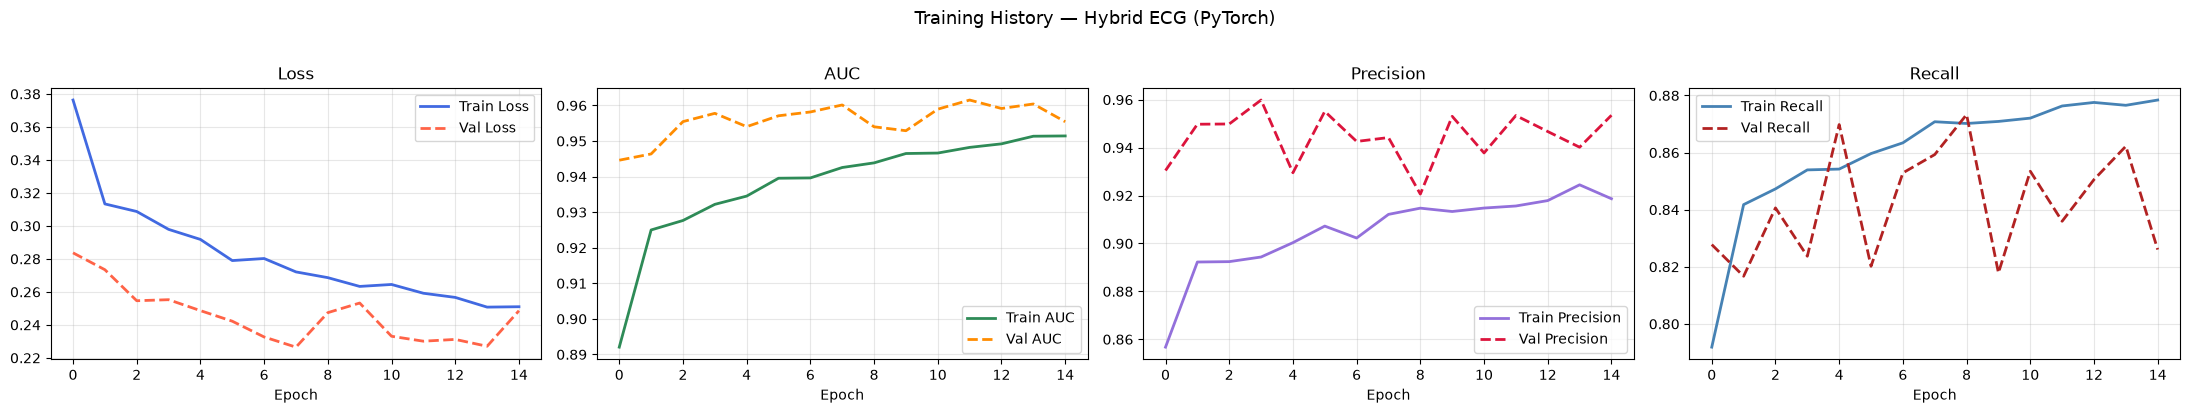

In [10]:
# ==========================================
# 10. STANDARD TRAINING PLOTS
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
pairs = [("loss","val_loss","Loss"), ("auc","val_auc","AUC"),
         ("precision","val_precision","Precision"), ("recall","val_recall","Recall")]
colors = [("royalblue","tomato"),("seagreen","darkorange"),
          ("mediumpurple","crimson"),("steelblue","firebrick")]
for ax, (m, vm, title), (c1, c2) in zip(axes, pairs, colors):
    ax.plot(history[m],  label=f"Train {title}", color=c1, linewidth=2)
    ax.plot(history[vm], label=f"Val {title}",   color=c2, linewidth=2, linestyle="--")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle("Training History — Hybrid ECG (PyTorch)", fontsize=13, y=1.02)
plt.tight_layout(); plt.savefig("logs/training_history.png", dpi=150, bbox_inches="tight"); plt.show()

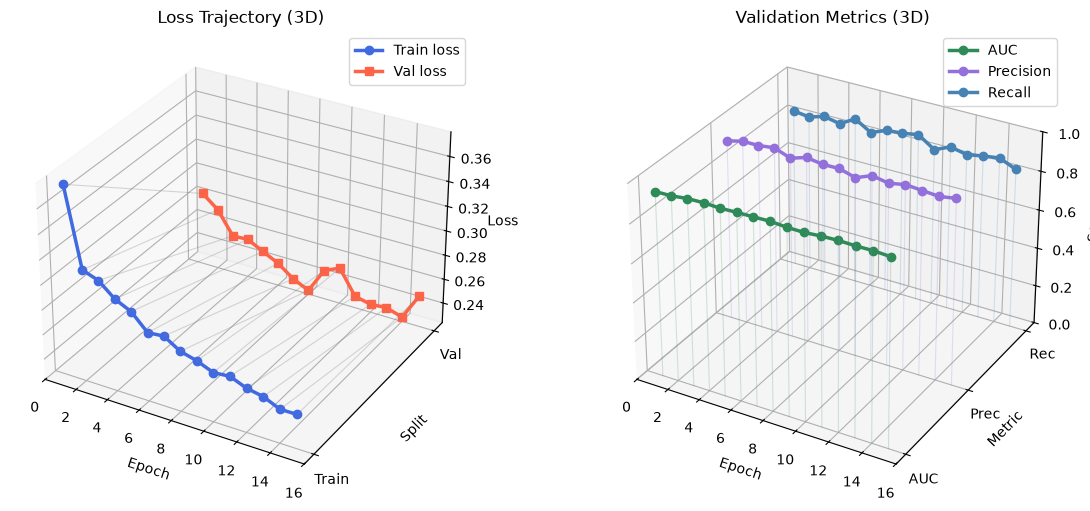

In [11]:
# ==========================================
# 11. 3D CHART — TRAINING TRAJECTORY (epoch × metric × value)
# ==========================================
fig = plt.figure(figsize=(14, 6))

# Panel A — Train vs Val loss surface as ribbons
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
epochs_axis = np.arange(1, len(history["loss"]) + 1)
ax1.plot(epochs_axis, np.zeros_like(epochs_axis), history["loss"],
         "o-", color="royalblue", linewidth=2.5, label="Train loss")
ax1.plot(epochs_axis, np.ones_like(epochs_axis),  history["val_loss"],
         "s-", color="tomato",    linewidth=2.5, label="Val loss")
for i, e in enumerate(epochs_axis):
    ax1.plot([e, e], [0, 1], [history["loss"][i], history["val_loss"][i]],
             color="gray", alpha=0.3, linewidth=0.8)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Split"); ax1.set_zlabel("Loss")
ax1.set_yticks([0, 1]); ax1.set_yticklabels(["Train", "Val"])
ax1.set_title("Loss Trajectory (3D)"); ax1.legend()

# Panel B — Multi-metric 3D surface (AUC / Precision / Recall over epochs)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
metrics_3d = [("val_auc","AUC",0),("val_precision","Precision",1),("val_recall","Recall",2)]
colors_3d  = ["seagreen","mediumpurple","steelblue"]
for (key, name, y), c in zip(metrics_3d, colors_3d):
    vals = history[key]
    ax2.plot(epochs_axis, [y]*len(vals), vals, "o-", color=c, linewidth=2.5, label=name)
    # vertical drop lines
    for i, e in enumerate(epochs_axis):
        ax2.plot([e, e], [y, y], [0, vals[i]], color=c, alpha=0.2, linewidth=0.8)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Metric"); ax2.set_zlabel("Score")
ax2.set_yticks([0,1,2]); ax2.set_yticklabels(["AUC","Prec","Rec"])
ax2.set_zlim(0, 1); ax2.set_title("Validation Metrics (3D)"); ax2.legend()

plt.tight_layout(); plt.savefig("logs/training_3d.png", dpi=150, bbox_inches="tight"); plt.show()

Test:   0%|          | 0/196 [00:00<?, ?it/s]


── Test Results ──────────────────────
  Loss      : 0.2253
  Accuracy  : 0.8926
  Auc       : 0.9625
  Precision : 0.9411
  Recall    : 0.8576
──────────────────────────────────────


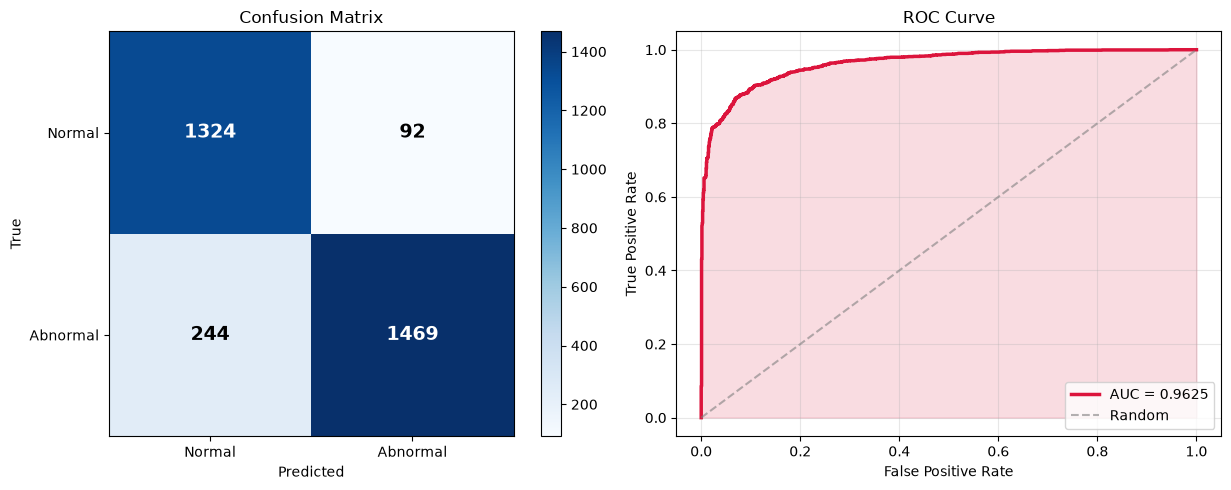

In [12]:
# ==========================================
# 12. TEST EVAL + CONFUSION MATRIX + ROC
# ==========================================
test = run_epoch(test_loader, train=False, desc="Test")

print("\n── Test Results ──────────────────────")
for k in ["loss","accuracy","auc","precision","recall"]:
    print(f"  {k.capitalize():<10}: {test[k]:.4f}")
print("──────────────────────────────────────")

probs_t, targets_t = test["probs"], test["targets"]
preds_t = (probs_t >= 0.5).astype(int)
cm = confusion_matrix(targets_t, preds_t)
fpr, tpr, thresh = roc_curve(targets_t, probs_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14, fontweight="bold")
ax.set_xticks([0,1]); ax.set_xticklabels(["Normal","Abnormal"])
ax.set_yticks([0,1]); ax.set_yticklabels(["Normal","Abnormal"])
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
plt.colorbar(im, ax=ax, fraction=0.046)

# ROC
ax = axes[1]
ax.plot(fpr, tpr, color="crimson", linewidth=2.5, label=f"AUC = {test['auc']:.4f}")
ax.plot([0,1],[0,1], "--", color="gray", alpha=0.6, label="Random")
ax.fill_between(fpr, tpr, alpha=0.15, color="crimson")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve"); ax.legend(loc="lower right"); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("logs/test_eval.png", dpi=150, bbox_inches="tight"); plt.show()

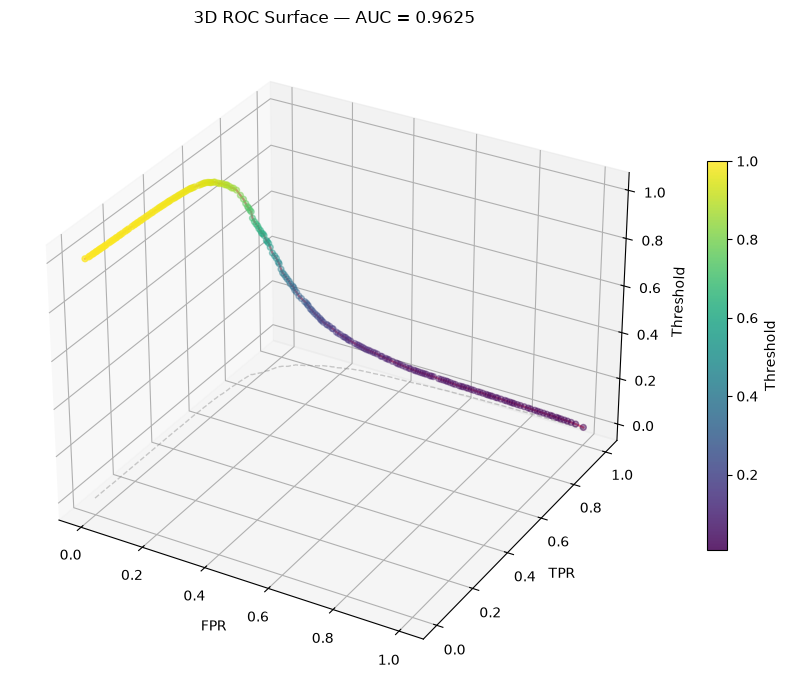

In [13]:
# ==========================================
# 13. 3D CHART — ROC TRAJECTORY (FPR × TPR × Threshold)
# ==========================================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

# Subsample for clarity
step = max(1, len(thresh) // 200)
fpr_s, tpr_s, thr_s = fpr[::step], tpr[::step], np.clip(thresh[::step], 0, 1)

# Color by threshold
sc = ax.scatter(fpr_s, tpr_s, thr_s, c=thr_s, cmap="viridis", s=18, alpha=0.85)
ax.plot(fpr_s, tpr_s, thr_s, color="crimson", linewidth=1.5, alpha=0.6)

# Project shadow onto FPR-TPR plane
ax.plot(fpr_s, tpr_s, np.zeros_like(thr_s), color="gray", linestyle="--", alpha=0.4, linewidth=1)

ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_zlabel("Threshold")
ax.set_title(f"3D ROC Surface — AUC = {test['auc']:.4f}")
fig.colorbar(sc, ax=ax, shrink=0.6, label="Threshold")
plt.tight_layout(); plt.savefig("logs/roc_3d.png", dpi=150, bbox_inches="tight"); plt.show()

Extracting embeddings from test set...


Embed:   0%|          | 0/196 [00:00<?, ?it/s]

Embedding matrix: (3129, 64)


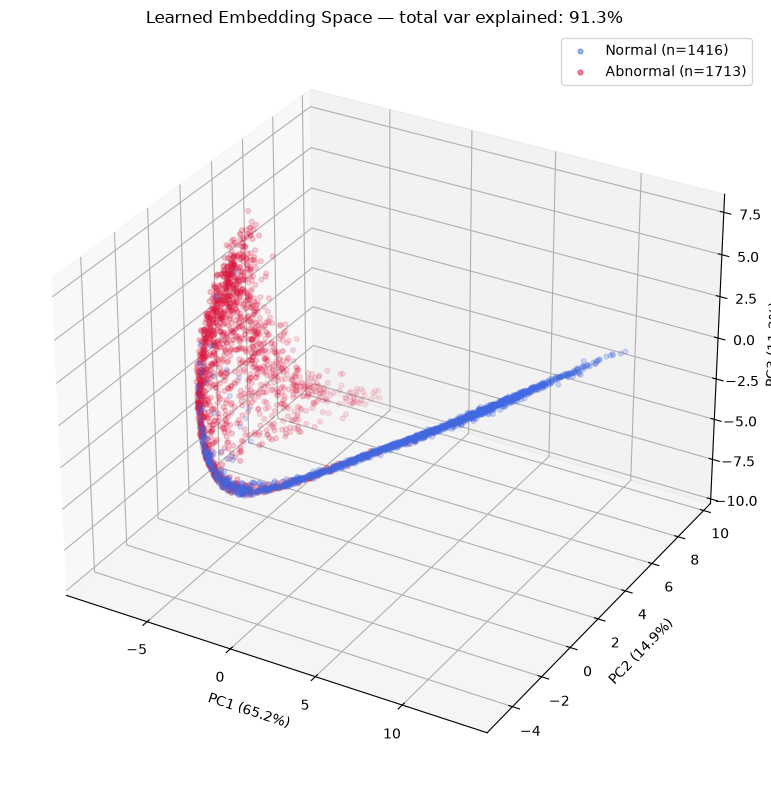

In [14]:
# ==========================================
# 14. 3D CHART — LEARNED EMBEDDING SPACE (PCA → 3D)
# ==========================================
print("Extracting embeddings from test set...")
model.eval()
all_emb, all_lab = [], []
with torch.no_grad():
    for signal, image, target in tqdm(test_loader, desc="Embed", leave=False):
        signal = signal.to(DEVICE, non_blocking=True)
        image  = image.to(DEVICE,  non_blocking=True)
        with autocast(device_type="cuda", enabled=USE_AMP):
            _, emb = model(signal, image, return_embedding=True)
        all_emb.append(emb.float().cpu().numpy())
        all_lab.append(target.numpy())

emb_mat = np.concatenate(all_emb, axis=0)
labels  = np.concatenate(all_lab, axis=0).astype(int)
print(f"Embedding matrix: {emb_mat.shape}")

# Reduce 64-D → 3-D with PCA
pca = PCA(n_components=3, random_state=SEED)
emb_3d = pca.fit_transform(emb_mat)
var_explained = pca.explained_variance_ratio_

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")
mask0 = labels == 0; mask1 = labels == 1
ax.scatter(emb_3d[mask0,0], emb_3d[mask0,1], emb_3d[mask0,2],
           c="royalblue", s=12, alpha=0.5, label=f"Normal (n={mask0.sum()})")
ax.scatter(emb_3d[mask1,0], emb_3d[mask1,1], emb_3d[mask1,2],
           c="crimson",   s=12, alpha=0.5, label=f"Abnormal (n={mask1.sum()})")
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%})")
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%})")
ax.set_zlabel(f"PC3 ({var_explained[2]:.1%})")
ax.set_title(f"Learned Embedding Space — total var explained: {var_explained.sum():.1%}")
ax.legend()
plt.tight_layout(); plt.savefig("logs/embedding_3d.png", dpi=150, bbox_inches="tight"); plt.show()

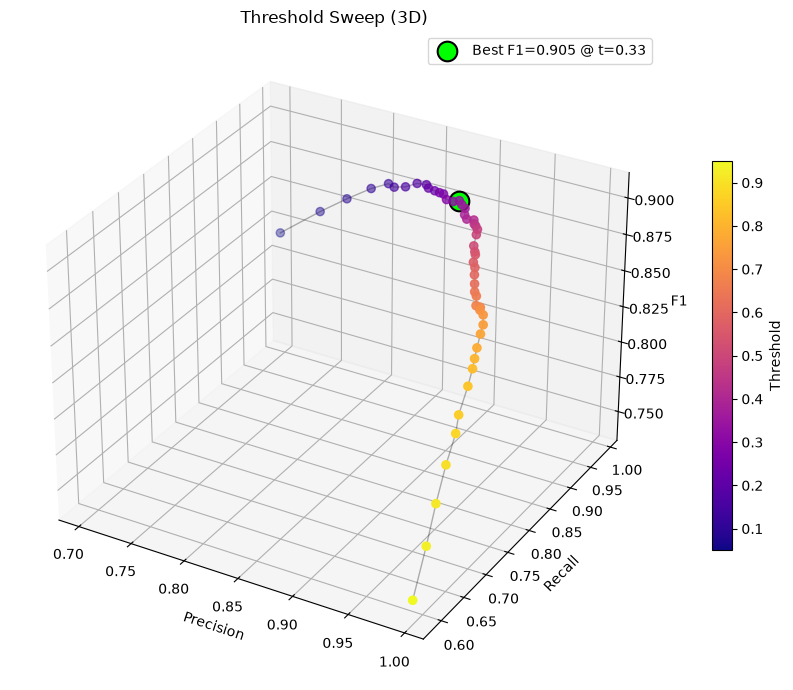


Optimal threshold (F1)  : 0.326
  precision: 0.9073
  recall   : 0.9031
  F1       : 0.9052


In [15]:
# ==========================================
# 15. 3D CHART — THRESHOLD SWEEP (Precision × Recall × F1)
# ==========================================
thresholds = np.linspace(0.05, 0.95, 50)
precs, recs, f1s = [], [], []
for t in thresholds:
    p = (probs_t >= t).astype(int)
    pr = precision_score(targets_t, p, zero_division=0)
    rc = recall_score(targets_t, p, zero_division=0)
    f1 = 2*pr*rc/(pr+rc) if (pr+rc) > 0 else 0.0
    precs.append(pr); recs.append(rc); f1s.append(f1)
precs, recs, f1s = map(np.array, (precs, recs, f1s))

best_idx = int(np.argmax(f1s))
best_t   = thresholds[best_idx]

fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
sc = ax.scatter(precs, recs, f1s, c=thresholds, cmap="plasma", s=35)
ax.plot(precs, recs, f1s, color="black", alpha=0.3, linewidth=1)
ax.scatter([precs[best_idx]],[recs[best_idx]],[f1s[best_idx]],
           color="lime", s=200, edgecolor="black", linewidth=1.5,
           label=f"Best F1={f1s[best_idx]:.3f} @ t={best_t:.2f}")
ax.set_xlabel("Precision"); ax.set_ylabel("Recall"); ax.set_zlabel("F1")
ax.set_title("Threshold Sweep (3D)")
fig.colorbar(sc, ax=ax, shrink=0.6, label="Threshold")
ax.legend()
plt.tight_layout(); plt.savefig("logs/threshold_3d.png", dpi=150, bbox_inches="tight"); plt.show()

print(f"\nOptimal threshold (F1)  : {best_t:.3f}")
print(f"  precision: {precs[best_idx]:.4f}")
print(f"  recall   : {recs[best_idx]:.4f}")
print(f"  F1       : {f1s[best_idx]:.4f}")

In [16]:
# ==========================================
# 16. SAVE FINAL MODEL + METADATA
# ==========================================
torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "use_high_res": USE_HIGH_RES,
        "signal_shape": EXPECTED_SIGNAL_SHAPE,
        "best_val_auc": float(best_auc),
        "best_epoch":   best_epoch,
        "test_auc":     float(test["auc"]),
        "optimal_threshold": float(best_t),
    },
}, "models/hybrid_ecg_model.pt")

print("\n✅ Hybrid ECG model trained and saved!")
print("   Artifacts in logs/:")
print("   - training_history.png")
print("   - training_3d.png")
print("   - test_eval.png  (confusion + ROC)")
print("   - roc_3d.png")
print("   - embedding_3d.png")
print("   - threshold_3d.png")
print("   - history.json")


✅ Hybrid ECG model trained and saved!
   Artifacts in logs/:
   - training_history.png
   - training_3d.png
   - test_eval.png  (confusion + ROC)
   - roc_3d.png
   - embedding_3d.png
   - threshold_3d.png
   - history.json
